In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# Setting the plotting style for Jupyter
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
def open_ds( file_path ):
    ds = xr.open_dataset(file_path)
    ds['longitude'] = ((ds.longitude + 180) % 360) - 180
    return ds

In [ ]:
def _crop_cerra(ds, lat_min, lat_max, lon_min, lon_max, grid_size=128):
    """
    Crops a square grid of grid_size from the CERRA dataset starting at the 
    bottom-left corner of the specified lat/lon box.
    """

    
    # 2. Define the mask based on the requested area
    mask = (
        (ds.latitude >= lat_min) & (ds.latitude <= lat_max) &
        (ds.longitude >= lon_min) & (ds.longitude <= lon_max)
    )
    
    # 3. Find indices in the projection space (x, y)
    arg_mask = np.argwhere(mask.values)
    
    if arg_mask.size == 0:
        raise ValueError(f"No data found for bounds: Lat({lat_min},{lat_max}), Lon({lon_min},{lon_max})")

    # Get the minimum indices (the "start" corner in projection space)
    y_idx_min, x_idx_min = arg_mask.min(axis=0)
    
    # 4. Check if the required rectangle fits in the domain
    # Using .sizes instead of .dims for future compatibility
    max_y, max_x = ds.sizes['y'], ds.sizes['x']
    
    y_idx_end = y_idx_min + grid_size
    x_idx_end = x_idx_min + grid_size
    
    # ERROR CHECK: Ensure the 128x128 box doesn't hang off the edge
    if x_idx_end > max_x or y_idx_end > max_y:
        raise IndexError(
            f"OUT OF BOUNDS ERROR: The requested {grid_size}x{grid_size} crop "
            f"starting at (y:{y_idx_min}, x:{x_idx_min}) would end at (y:{y_idx_end}, x:{x_idx_end}), "
            f"which exceeds the dataset limits (max_y:{max_y}, max_x:{max_x})."
        )
    
    # 5. Perform the crop
    ds_cerra_sub = ds.isel(
        x=slice(x_idx_min, x_idx_end),
        y=slice(y_idx_min, y_idx_end)
    )
    
    # 6. Final Validation
    print(f"Crop Successful: Start(y:{y_idx_min}, x:{x_idx_min}) -> End(y:{y_idx_end}, x:{x_idx_end})")
    
    # Check for NaNs
    nan_count = ds_cerra_sub.t2m.isnull().sum().values
    if nan_count > 0:
        print(f"WARNING: Subdomain contains {nan_count} NaNs.")
    else:
        print("Success: No NaNs found in the cropped domain.")
    
    return ds_cerra_sub

In [ ]:

def plot_t2m(data_to_plot, name):
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add high-resolution map features
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=1)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':', alpha=0.7)
    ax.add_feature(cfeature.LAND, facecolor='#f9f9f9')
    
    # The actual plotting
    mesh = data_to_plot.plot(
        ax=ax, 
        x='longitude', y='latitude', 
        transform=ccrs.PlateCarree(),
        cmap='RdYlBu_r', 
        cbar_kwargs={'label': '2m Temperature [K]', 'shrink': 0.8}
    )
    
    # Zoom the map to the actual limits of the cropped dataset
    # This is more robust than using the original lon_min/max
    ax.set_extent([
        data_to_plot.longitude.min(), data_to_plot.longitude.max(), 
        data_to_plot.latitude.min(), data_to_plot.latitude.max()
    ], crs=ccrs.PlateCarree())
    
    # Extract date for title
    time_str = data_to_plot.valid_time.dt.strftime('%Y-%m-%d %H:%M').values
    plt.title(f"{name} T2M - {time_str}", loc='left', fontsize=12)
    plt.show()

In [ ]:
# ERA 5

In [ ]:
import xarray as xr
import numpy as np

def era5_to_cerra(ds_era5,ds_cerra_sub):
    # 2. Normalize Longitude and Sort (Essential for interpolation)
    ds_era5['longitude'] = ((ds_era5.longitude + 180) % 360) - 180
    ds_era5 = ds_era5.sortby(['latitude', 'longitude'])
    
    # 3. Define a Buffer (approx 2 degrees) to ensure interpolation coverage
    buffer = 2.0
    era5_lat_min = ds_cerra_sub.latitude.min().values - buffer
    era5_lat_max = ds_cerra_sub.latitude.max().values + buffer
    era5_lon_min = ds_cerra_sub.longitude.min().values - buffer
    era5_lon_max = ds_cerra_sub.longitude.max().values + buffer
    
    # 4. Pre-crop ERA5 (using slice because ERA5 is a regular grid)
    # Note: ERA5 latitudes are often stored decreasingly (90 to -90), 
    # so we use sortby to make indexing safer.
    ds_era5_cropped = ds_era5.sel(
        latitude=slice(era5_lat_min, era5_lat_max),
        longitude=slice(era5_lon_min, era5_lon_max)
    )
  
    # Interpolate ERA5 onto the CERRA 2D coordinate arrays
    # This creates an ERA5 dataset that has 'x' and 'y' as dimensions
    ds_era5_on_cerra = ds_era5_cropped.interp(
        latitude=ds_cerra_sub.latitude, 
        longitude=ds_cerra_sub.longitude, 
        method='linear'
    )
    
    # Force the interpolated coordinates to match CERRA exactly
    ds_era5_on_cerra = ds_era5_on_cerra.assign_coords(x=ds_cerra_sub.x, y=ds_cerra_sub.y)
    return ds_era5_on_cerra, ds_era5_cropped


 

In [ ]:
def plot_all(ds_era5_on_cerra, ds_cerra_sub, idx ):

    # Selection
    
    cerra_vals = ds_cerra_sub['t2m'].isel(**idx)
    era5_vals = ds_era5_on_cerra['t2m'].isel(**idx)
    bias = cerra_vals - era5_vals
    
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Plotting helper
    titles = ["CERRA (Native)", "ERA5 (Interp to CERRA)", "Bias (CERRA - ERA5)"]
    datas = [cerra_vals, era5_vals, bias]
    cmaps = ['RdYlBu_r', 'RdYlBu_r', 'bwr']
    
    for ax, data, title, cmap in zip(axes, datas, titles, cmaps):
        # We use x='longitude', y='latitude' for plotting on PlateCarree
        im = data.plot(ax=ax, x='longitude', y='latitude', transform=ccrs.PlateCarree(),
                       cmap=cmap, add_colorbar=True, cbar_kwargs={'shrink': 0.8})
        ax.coastlines()
        ax.set_title(title)
        # Set zoom
        ax.set_extent([ds_cerra_sub.longitude.min(), ds_cerra_sub.longitude.max(), 
                       ds_cerra_sub.latitude.min(), ds_cerra_sub.latitude.max()])
    
    plt.tight_layout()
    plt.show()

In [ ]:
cerra_file = '/lus/h2resw01/scratch/swe4281/CERRA_DATA2026/CERRA_DATA/cerra_t2m_202410_0000.nc'
era5_file  = '/lus/h2resw01/scratch/swe4281/CERRA_DATA2026/ERA5EDA_DATA/erra5eda_t2m_202410_0000.nc'

In [9]:
cerra_ds = open_ds(cerra_file)
era5_ds = open_ds(era5_file)

In [19]:
ds_cerra_sub = _crop_cerra(cerra_ds,50, 80,1, 30,128)
ds_era5_on_cerra,  ds_era5_cropped= era5_to_cerra(era5_ds,ds_cerra_sub)

Crop Successful: Start(y:293, x:237) -> End(y:421, x:365)
Success: No NaNs found in the cropped domain.


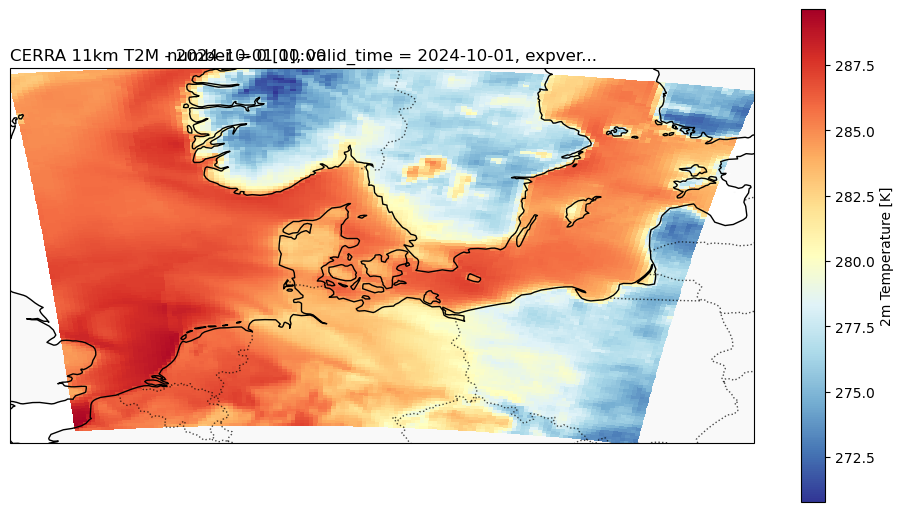

In [20]:
plot_t2m(ds_cerra_sub['t2m'].isel(number=0, valid_time=0), "CERRA 11km")

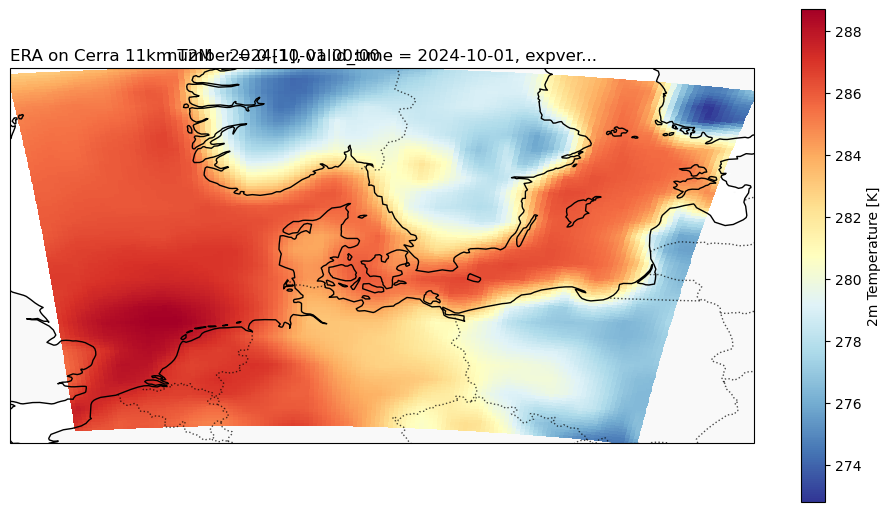

In [21]:
plot_t2m(ds_era5_on_cerra['t2m'].isel(number=0, valid_time=0), "ERA on Cerra 11km")

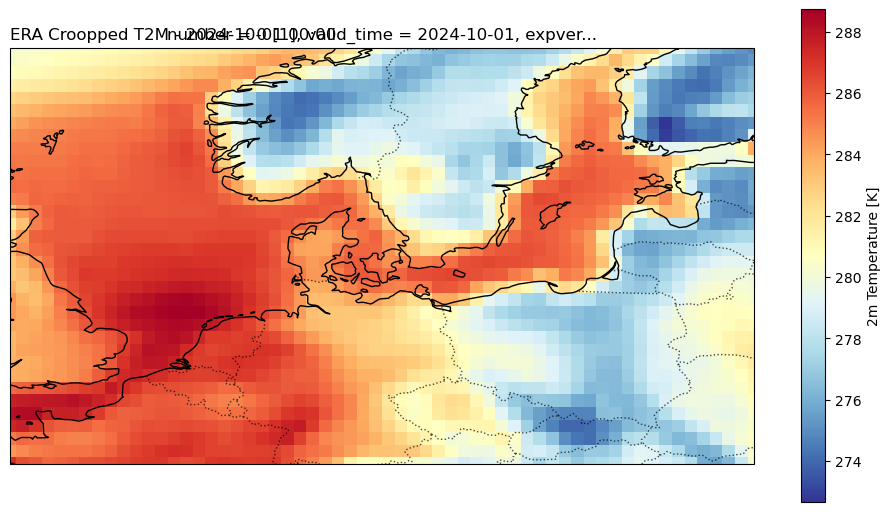

In [22]:
plot_t2m(ds_era5_cropped['t2m'].isel(number=0, valid_time=0), "ERA Croopped")

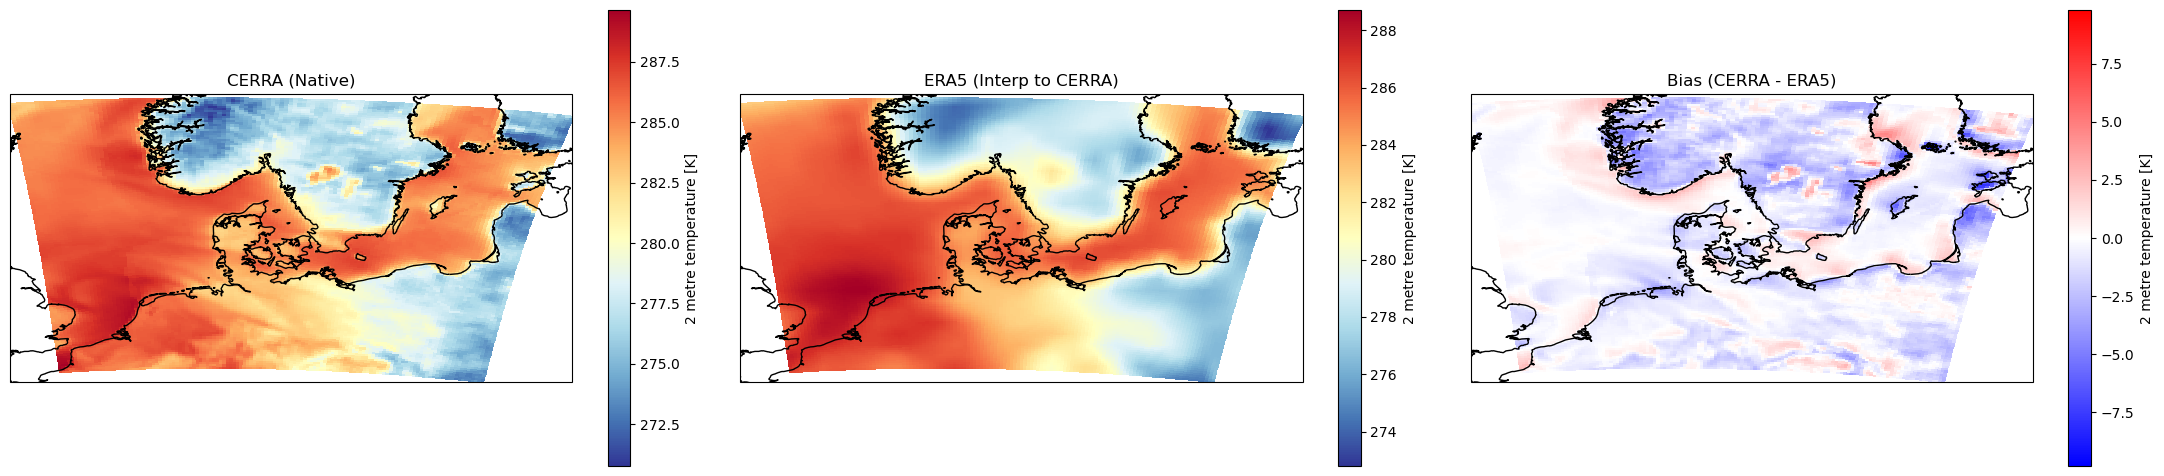

In [14]:
plot_all(ds_era5_on_cerra,ds_cerra_sub, dict(number=0, valid_time=0))